# TP Final : Classification de Sentiments Avancée - CORRECTION

## Imports et Configuration

In [1]:
# Imports de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP et prétraitement
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn - Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2

# Modèles ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# Métriques et évaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)

# Word2Vec
from gensim.models import Word2Vec

# Téléchargement des ressources NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Phase 1 : Exploration et Préparation

### 1.1 - Chargement et exploration des données

In [2]:
# Chargement du dataset IMDB
# Option 1 : Via keras (recommandé)
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Charger les données avec le mapping des mots
(X_train_idx, y_train), (X_test_idx, y_test) = imdb.load_data(num_words=10000)

# Récupérer le dictionnaire de mapping index -> mot
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

# Fonction pour décoder les critiques
def decode_review(encoded_review):
    # Les indices sont décalés de 3 (0=padding, 1=start, 2=unknown)
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# Décoder toutes les critiques
X_train_text = [decode_review(review) for review in X_train_idx]
X_test_text = [decode_review(review) for review in X_test_idx]

# Créer des DataFrames
df_train = pd.DataFrame({'review': X_train_text, 'sentiment': y_train})
df_test = pd.DataFrame({'review': X_test_text, 'sentiment': y_test})

# Combiner pour l'exploration
df = pd.concat([df_train, df_test], ignore_index=True)

df.head()

,review,sentiment
0,? this film was just brilliant casting locatio...,1
1,? big hair big boobs bad music and a giant saf...,0
2,? this has to be one of the worst films of the...,0
3,? the ? ? at storytelling the traditional sort...,1
4,? worst mistake of my life br br i picked this...,0


In [3]:
# Exploration de la structure des données
print("Informations sur le dataset :")
print(df.info())

print("Statistiques descriptives :")
print(df.describe())

print("Valeurs manquantes :")
print(df.isnull().sum())

# Distribution des classes
print("Distribution des sentiments :")
print(df['sentiment'].value_counts())
print(f"Pourcentage de positifs : {df['sentiment'].mean()*100:.2f}%")
print(f"Pourcentage de négatifs : {(1-df['sentiment'].mean())*100:.2f}%")

Informations sur le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 56.9 MB
None
Statistiques descriptives :
          sentiment
count  50000.000000
mean       0.500000
std        0.500005
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
Valeurs manquantes :
review       0
sentiment    0
dtype: int64
Distribution des sentiments :
sentiment
1    25000
0    25000
Name: count, dtype: int64
Pourcentage de positifs : 50.00%
Pourcentage de négatifs : 50.00%


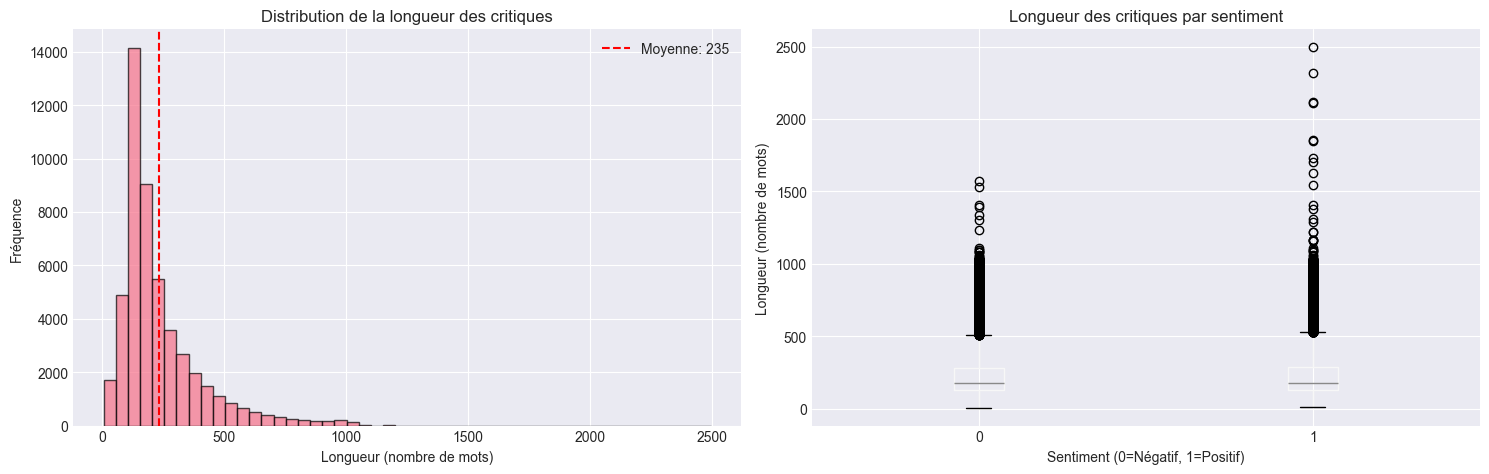

In [4]:
df['length'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme global
axes[0].hist(df['length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Longueur (nombre de mots)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la longueur des critiques')
axes[0].axvline(df['length'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["length"].mean():.0f}')
axes[0].legend()

# Boxplot par sentiment
df.boxplot(column='length', by='sentiment', ax=axes[1])
axes[1].set_xlabel('Sentiment (0=Négatif, 1=Positif)')
axes[1].set_ylabel('Longueur (nombre de mots)')
axes[1].set_title('Longueur des critiques par sentiment')
plt.suptitle('')

plt.tight_layout()
plt.show()

### 1.2 - Nettoyage des données

In [5]:
def clean_text(text):
    # Supprimer les balises HTML
    text = re.sub(r'<.*?>', '', text)
    
    # Supprimer les URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Conserver uniquement les lettres et espaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convertir en minuscules
    text = text.lower()
    
    # Tokenisation
    tokens = word_tokenize(text)
    
    # Supprimer les stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # Lemmatisation
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Rejoindre les tokens
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

df['cleaned_review'] = df['review'].apply(clean_text)

### 1.3 - Analyse exploratoire

In [6]:
# Vérifier la qualité du nettoyage
df['cleaned_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

print(df['cleaned_length'].describe())

# Statistiques par classe
stats_by_sentiment = df.groupby('sentiment').agg({
    'cleaned_length': ['count', 'mean', 'std', 'min', 'max']
})
print(stats_by_sentiment)

count    50000.000000
mean       105.168100
std         76.955514
min          3.000000
25%         58.000000
50%         79.000000
75%        128.000000
max       1107.000000
Name: cleaned_length, dtype: float64
          cleaned_length                              
                   count      mean       std min   max
sentiment                                             
0                  25000  104.6324  74.45365   3   683
1                  25000  105.7038  79.37644   5  1107


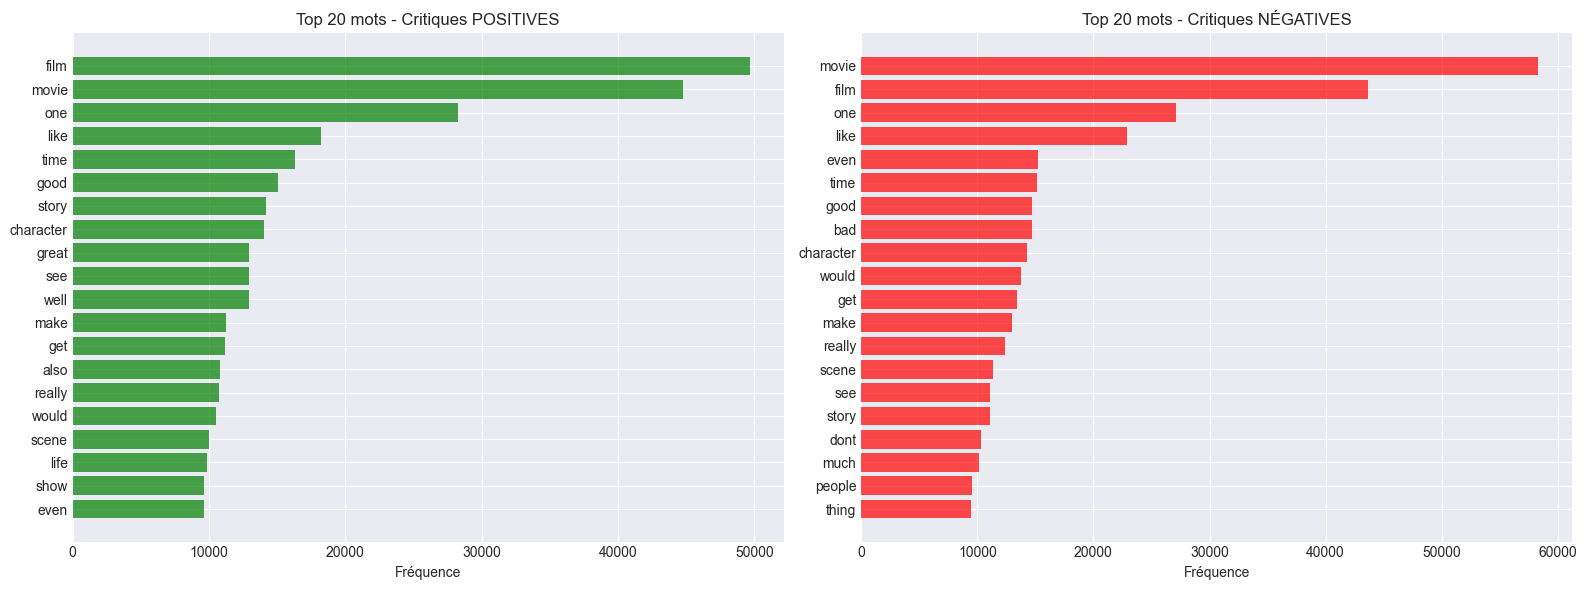

In [7]:
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

# Mots positifs
positive_reviews = df[df['sentiment'] == 1]['cleaned_review']
top_positive = get_top_words(positive_reviews, 20)

# Mots négatifs
negative_reviews = df[df['sentiment'] == 0]['cleaned_review']
top_negative = get_top_words(negative_reviews, 20)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mots positifs
words_pos, counts_pos = zip(*top_positive)
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 20 mots - Critiques POSITIVES')
axes[0].invert_yaxis()

# Mots négatifs
words_neg, counts_neg = zip(*top_negative)
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 20 mots - Critiques NÉGATIVES')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

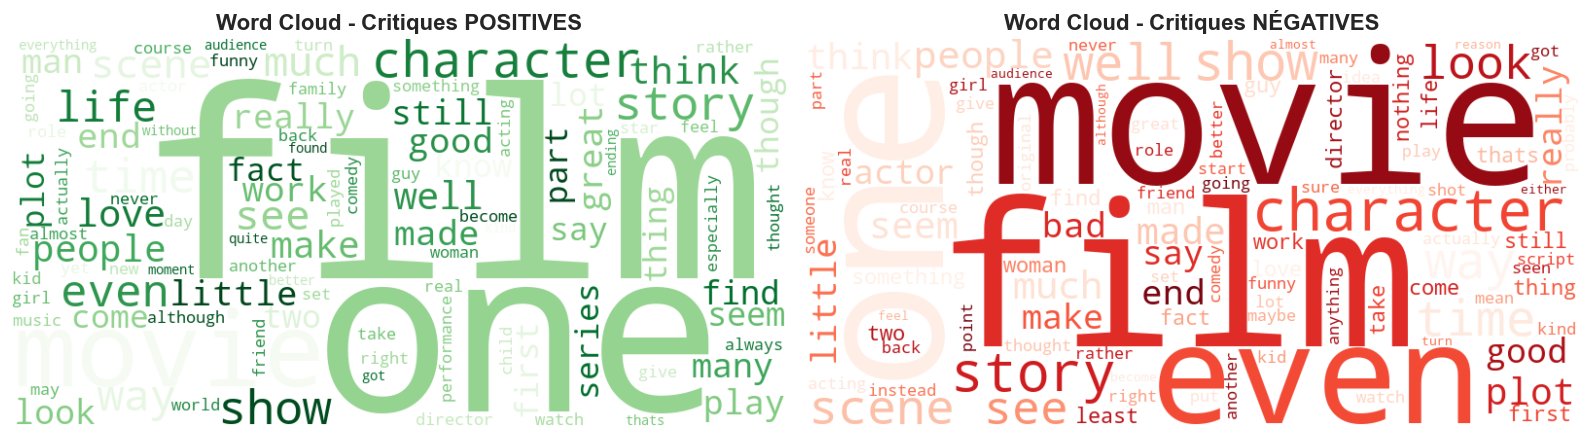

In [8]:
# Word clouds par sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
positive_text = ' '.join(positive_reviews)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Critiques POSITIVES', fontsize=16, fontweight='bold')

# Word cloud négatif
negative_text = ' '.join(negative_reviews)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Critiques NÉGATIVES', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Phase 2 : Feature Engineering

### 2.1 - Vectorisation TF-IDF

In [9]:
# Split train/test en utilisant les indices originaux
# On prend les 25000 premières pour train, les 25000 suivantes pour test
split_idx = 25000
df_train = df[:split_idx].copy()
df_test = df[split_idx:].copy()

X_train = df_train['cleaned_review']
y_train = df_train['sentiment']
X_test = df_test['cleaned_review']
y_test = df_test['sentiment']

print(f"Train set : {len(X_train)} critiques")
print(f"Test set : {len(X_test)} critiques")
print(f"Distribution train : {y_train.mean()*100:.2f}% positifs")
print(f"Distribution test : {y_test.mean()*100:.2f}% positifs")

Train set : 25000 critiques
Test set : 25000 critiques
Distribution train : 50.00% positifs
Distribution test : 50.00% positifs


In [10]:
# Vectorisation TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    norm='l2'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape train TF-IDF : {X_train_tfidf.shape}")
print(f"Shape test TF-IDF : {X_test_tfidf.shape}")
print(f"Nombre de features : {len(tfidf_vectorizer.get_feature_names_out())}")

Shape train TF-IDF : (25000, 5000)
Shape test TF-IDF : (25000, 5000)
Nombre de features : 5000


### 2.2 - Features Word2Vec

In [11]:
# Tokeniser les critiques nettoyées
train_tokens = [review.split() for review in X_train]
test_tokens = [review.split() for review in X_test]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_STATE
)

print(f"Vocabulaire Word2Vec : {len(w2v_model.wv)} mots")
print(f"Dimension des embeddings : {w2v_model.wv.vector_size}")

Vocabulaire Word2Vec : 8345 mots
Dimension des embeddings : 100


In [12]:
# Fonction pour créer des embeddings de documents (moyenne des vecteurs de mots)
def document_vector(tokens, model):
    # Filtrer les mots présents dans le vocabulaire
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    
    return np.mean(vectors, axis=0)

# Créer les embeddings pour train et test
X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in train_tokens])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in test_tokens])

print(f"Shape train Word2Vec : {X_train_w2v.shape}")
print(f"Shape test Word2Vec : {X_test_w2v.shape}")

Shape train Word2Vec : (25000, 100)
Shape test Word2Vec : (25000, 100)


In [13]:
# Tester Word2Vec : mots similaires
test_words = ['good', 'bad', 'excellent', 'terrible', 'love', 'hate']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"'{word}' : {[w for w, _ in similar]}")

'good' : ['great', 'decent', 'bad', 'okay', 'fine']
'bad' : ['terrible', 'awful', 'suck', 'horrible', 'good']
'excellent' : ['outstanding', 'superb', 'fine', 'terrific', 'fantastic']
'terrible' : ['horrible', 'awful', 'atrocious', 'dreadful', 'sucked']
'love' : ['asleep', 'hate', 'apart', 'loved', 'romance']
'hate' : ['dislike', 'hated', 'suck', 'sorry', 'anyways']


### 2.3 - Feature Selection et analyse

In [14]:
# Analyse de l'importance des features TF-IDF avec chi2
from sklearn.feature_selection import chi2

# Calculer chi2 pour chaque feature
chi2_scores, p_values = chi2(X_train_tfidf, y_train)

feature_names = tfidf_vectorizer.get_feature_names_out()

# Créer un DataFrame pour l'analyse
feature_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi2_scores
}).sort_values('chi2_score', ascending=False)

print("Top 20 features les plus discriminantes (chi2) :")
print(feature_scores.head(20))

print("Bottom 20 features (moins discriminantes) :")
print(feature_scores.tail(20))

Top 20 features les plus discriminantes (chi2) :
          feature  chi2_score
283           bad  176.390231
4918        worst  144.305022
4783        waste  106.812339
271         awful   96.378491
1922        great   81.718466
4394     terrible   74.426077
4785   waste time   70.309324
1410    excellent   65.870565
4920  worst movie   64.454538
4917        worse   64.237423
2103     horrible   63.946035
446        boring   63.360513
4246       stupid   62.342569
4896    wonderful   60.828847
905          crap   51.566522
3155    one worst   50.825531
3356         poor   49.828679
3119     one best   46.684201
3063      nothing   45.659304
3357       poorly   44.332765
Bottom 20 features (moins discriminantes) :
           feature    chi2_score
2720    meaningful  3.954811e-05
1708        flower  3.635745e-05
2850   movie based  2.856971e-05
3895       selling  2.610729e-05
3163         opera  2.485652e-05
1748         forty  2.462273e-05
81            aged  2.356951e-05
1961         

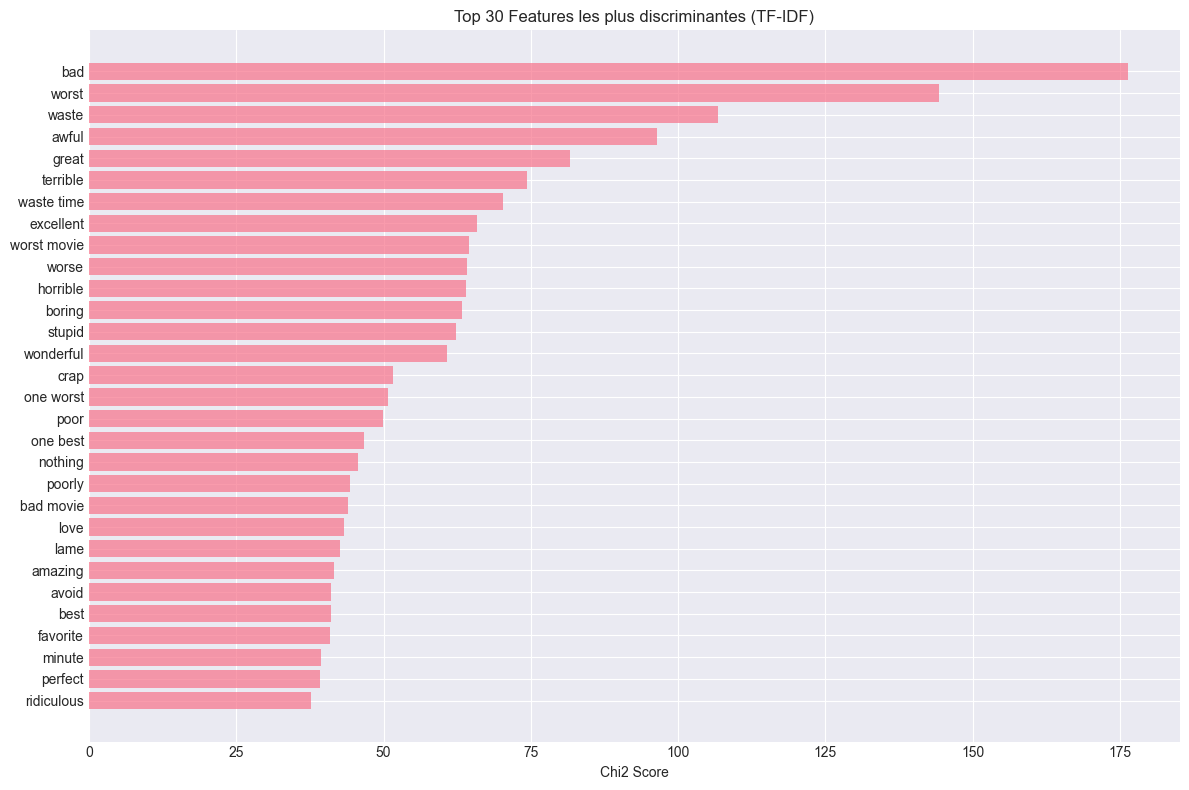

In [15]:
# Visualisation des top features
plt.figure(figsize=(12, 8))
top_30 = feature_scores.head(30)
plt.barh(range(30), top_30['chi2_score'].values, alpha=0.7)
plt.yticks(range(30), top_30['feature'].values)
plt.xlabel('Chi2 Score')
plt.title('Top 30 Features les plus discriminantes (TF-IDF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Phase 3 : Modélisation Avancée

### 3.1 - Modèle 1 : Logistic Regression avec GridSearch

In [16]:
# Logistic Regression avec optimisation
# Paramètres à tester
param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}


lr = LogisticRegression(random_state=RANDOM_STATE)
grid_lr = GridSearchCV(
    lr, 
    param_grid_lr, 
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


grid_lr.fit(X_train_tfidf, y_train)

print(f"\nMeilleurs paramètres : {grid_lr.best_params_}")
print(f"Meilleur score CV : {grid_lr.best_score_:.4f}")

# Prédiction sur le test set
y_pred_lr = grid_lr.predict(X_test_tfidf)
y_proba_lr = grid_lr.predict_proba(X_test_tfidf)[:, 1]

# Métriques
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Accuracy : {acc_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print(f"ROC-AUC : {auc_lr:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Meilleurs paramètres : {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Meilleur score CV : 0.8821
Accuracy : 0.8829
F1-Score : 0.8834
ROC-AUC : 0.9535


### 3.2 - Modèle 2 : SVM

In [17]:
# SVM avec optimisation
# On utilise un sous-ensemble pour SVM (plus rapide)
# En production, utilisez le dataset complet
sample_size = 10000
X_train_svm = X_train_tfidf[:sample_size]
y_train_svm = y_train[:sample_size]

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC(random_state=RANDOM_STATE, probability=True)
grid_svm = GridSearchCV(
    svm, 
    param_grid_svm, 
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_svm, y_train_svm)

print(f"\nMeilleurs paramètres : {grid_svm.best_params_}")
print(f"Meilleur score CV : {grid_svm.best_score_:.4f}")

# Prédiction
y_pred_svm = grid_svm.predict(X_test_tfidf)
y_proba_svm = grid_svm.predict_proba(X_test_tfidf)[:, 1]

# Métriques
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

print(f"Accuracy : {acc_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")
print(f"ROC-AUC : {auc_svm:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Meilleurs paramètres : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Meilleur score CV : 0.8730
Accuracy : 0.8741
F1-Score : 0.8744
ROC-AUC : 0.9468


### 3.3 - Modèle 3 : Random Forest

In [18]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
grid_rf = GridSearchCV(
    rf, 
    param_grid_rf, 
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_tfidf, y_train)

print(f"Meilleurs paramètres : {grid_rf.best_params_}")
print(f"Meilleur score CV : {grid_rf.best_score_:.4f}")

# Prédiction
y_pred_rf = grid_rf.predict(X_test_tfidf)
y_proba_rf = grid_rf.predict_proba(X_test_tfidf)[:, 1]

# Métriques
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Accuracy : {acc_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC : {auc_rf:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score CV : 0.8478
Accuracy : 0.8504
F1-Score : 0.8504
ROC-AUC : 0.9287


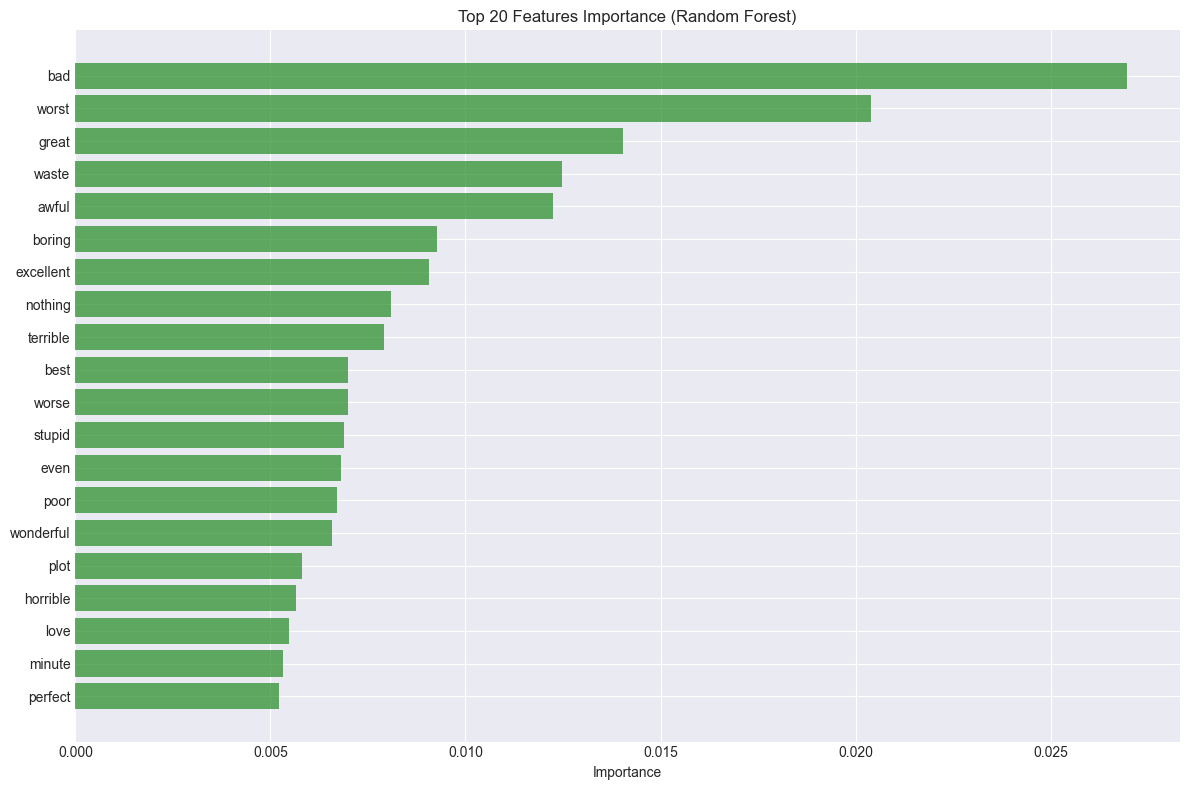

In [19]:
# Feature importance du Random Forest
feature_importance = grid_rf.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_20_features = feature_importance_df.head(20)
plt.barh(range(20), top_20_features['importance'].values, alpha=0.7, color='forestgreen')
plt.yticks(range(20), top_20_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 20 Features Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.4 - Modèle 4 : Ensemble Learning (Voting Classifier)

In [20]:
# Ensemble : Voting Classifier
# Utiliser les meilleurs modèles trouvés
lr_best = grid_lr.best_estimator_
rf_best = grid_rf.best_estimator_
nb = MultinomialNB()  # Naive Bayes fonctionne bien avec TF-IDF

# Entraîner Naive Bayes
nb.fit(X_train_tfidf, y_train)

# Créer le Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_best),
        ('rf', rf_best),
        ('nb', nb)
    ],
    voting='soft',  # Utilise les probabilités
    n_jobs=-1
)

voting_clf.fit(X_train_tfidf, y_train)

# Prédiction
y_pred_voting = voting_clf.predict(X_test_tfidf)
y_proba_voting = voting_clf.predict_proba(X_test_tfidf)[:, 1]

# Métriques
acc_voting = accuracy_score(y_test, y_pred_voting)
f1_voting = f1_score(y_test, y_pred_voting)
auc_voting = roc_auc_score(y_test, y_proba_voting)

print(f"Accuracy : {acc_voting:.4f}")
print(f"F1-Score : {f1_voting:.4f}")
print(f"ROC-AUC : {auc_voting:.4f}")

Accuracy : 0.8808
F1-Score : 0.8815
ROC-AUC : 0.9518


### 3.5 - Modèle 5 : Gradient Boosting

In [21]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE,
    verbose=1
)

gb.fit(X_train_tfidf, y_train)

# Prédiction
y_pred_gb = gb.predict(X_test_tfidf)
y_proba_gb = gb.predict_proba(X_test_tfidf)[:, 1]

# Métriques
acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)

print(f"Accuracy : {acc_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")
print(f"ROC-AUC : {auc_gb:.4f}")

      Iter       Train Loss   Remaining Time 
         1           1.3442            1.27m
         2           1.3094            1.22m
         3           1.2793            1.20m
         4           1.2539            1.19m
         5           1.2313            1.17m
         6           1.2114            1.15m
         7           1.1938            1.14m
         8           1.1767            1.13m
         9           1.1615            1.11m
        10           1.1467            1.10m
        20           1.0369           57.33s
        30           0.9609           49.62s
        40           0.9041           42.27s
        50           0.8576           35.11s
        60           0.8180           28.04s
        70           0.7851           20.94s
        80           0.7571           13.89s
        90           0.7307            6.93s
       100           0.7087            0.00s
Accuracy : 0.8268
F1-Score : 0.8325
ROC-AUC : 0.9121


## Phase 4 : Comparaison et Sélection du Meilleur Modèle

In [22]:
# Tableau comparatif de tous les modèles
results = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'SVM', 'Random Forest', 'Naive Bayes', 'Voting Classifier', 'Gradient Boosting'],
    'Accuracy': [acc_lr, acc_svm, acc_rf, accuracy_score(y_test, nb.predict(X_test_tfidf)), acc_voting, acc_gb],
    'F1-Score': [f1_lr, f1_svm, f1_rf, f1_score(y_test, nb.predict(X_test_tfidf)), f1_voting, f1_gb],
    'ROC-AUC': [auc_lr, auc_svm, auc_rf, roc_auc_score(y_test, nb.predict_proba(X_test_tfidf)[:, 1]), auc_voting, auc_gb]
}).sort_values('ROC-AUC', ascending=False)


print(results.to_string(index=False))

             Modèle  Accuracy  F1-Score  ROC-AUC
Logistic Regression   0.88288  0.883421 0.953529
  Voting Classifier   0.88076  0.881495 0.951797
                SVM   0.87412  0.874436 0.946770
        Naive Bayes   0.85312  0.853226 0.928877
      Random Forest   0.85040  0.850412 0.928740
  Gradient Boosting   0.82676  0.832489 0.912111


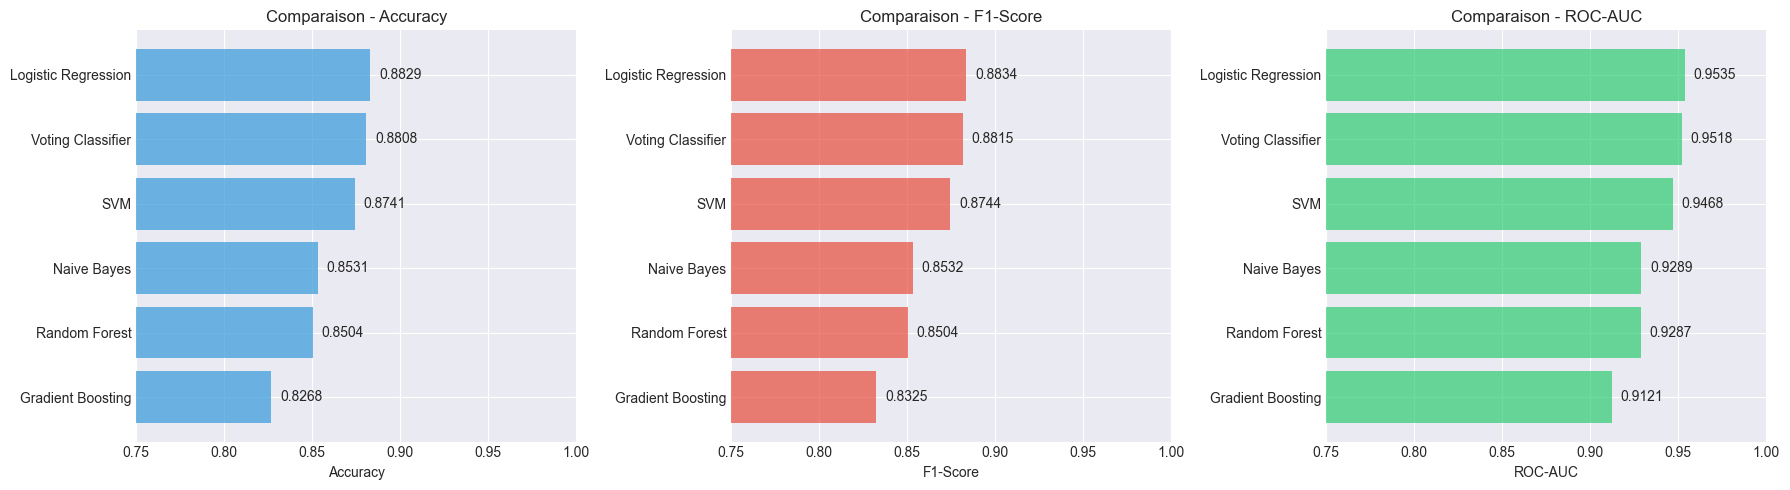

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    sorted_results = results.sort_values(metric, ascending=True)
    axes[idx].barh(sorted_results['Modèle'], sorted_results[metric], color=colors[idx], alpha=0.7)
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'Comparaison - {metric}')
    axes[idx].set_xlim([0.75, 1.0])
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(sorted_results[metric]):
        axes[idx].text(v + 0.005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

In [24]:
# Sélection du meilleur modèle
best_model_name = results.iloc[0]['Modèle']
best_auc = results.iloc[0]['ROC-AUC']

print(f"MEILLEUR MODÈLE : {best_model_name}")
print(f"ROC-AUC Score : {best_auc:.4f}")

best_model = grid_lr.best_estimator_
y_pred_best = y_pred_voting
y_proba_best = y_proba_voting

MEILLEUR MODÈLE : Logistic Regression
ROC-AUC Score : 0.9535


## Phase 5 : Évaluation Complète du Meilleur Modèle

### 5.1 - Métriques détaillées

In [25]:
print(classification_report(y_test, y_pred_best, target_names=['Négatif', 'Positif']))

              precision    recall  f1-score   support

     Négatif       0.89      0.87      0.88     12500
     Positif       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



### 5.2 - Matrice de confusion

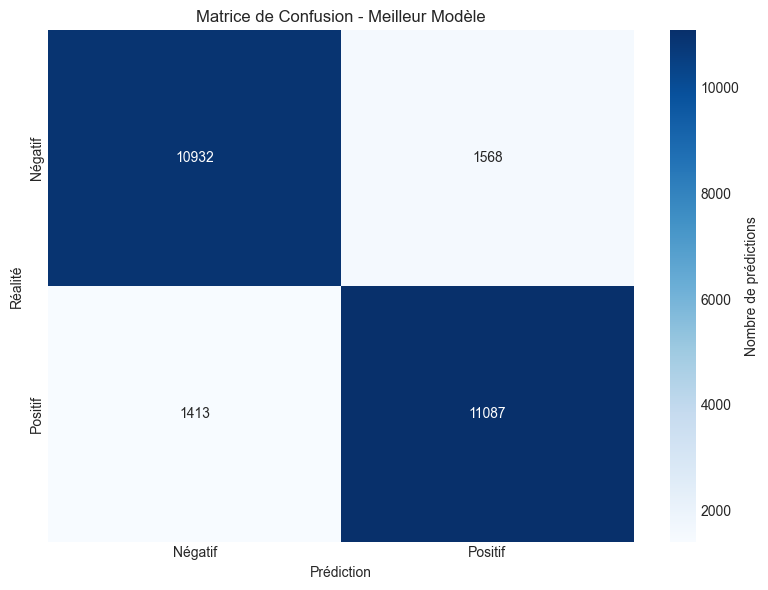

In [26]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Meilleur Modèle')

plt.tight_layout()
plt.show()

### 5.3 - Courbes ROC et Precision-Recall

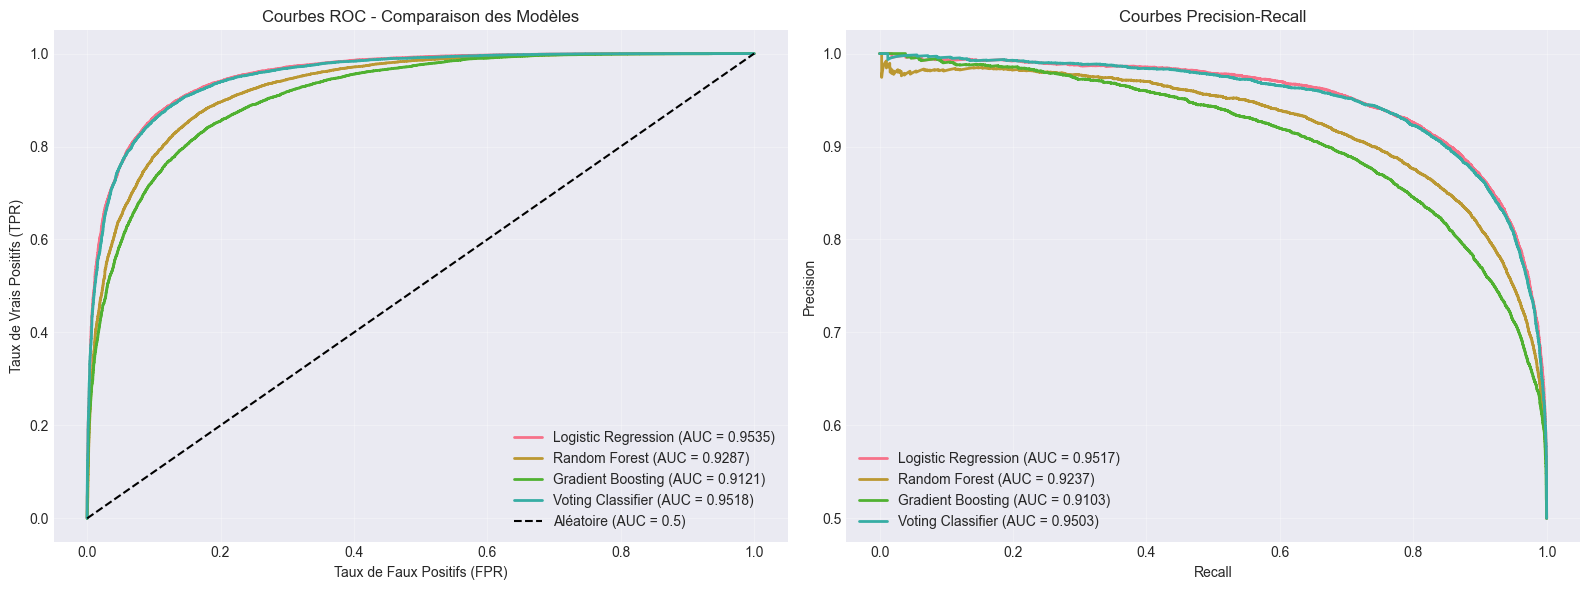

In [27]:
# Courbes ROC pour tous les modèles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbe ROC
models_data = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('Gradient Boosting', y_proba_gb),
    ('Voting Classifier', y_proba_voting)
]

for name, y_proba in models_data:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)')
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].set_title('Courbes ROC - Comparaison des Modèles')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Courbe Precision-Recall
for name, y_proba in models_data:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{name} (AUC = {pr_auc:.4f})', linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbes Precision-Recall')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 6 : Déploiement

### 6.1 - Pipeline de prédiction

In [28]:
# Fonction complète de prédiction
def predict_sentiment(text, return_proba=True):
    # Nettoyage du texte
    cleaned = clean_text(text)
    
    # Vectorisation
    vectorized = tfidf_vectorizer.transform([cleaned])
    
    # Prédiction
    prediction = best_model.predict(vectorized)[0]
    
    result = {
        'text': text,
        'cleaned_text': cleaned,
        'prediction': 'POSITIF' if prediction == 1 else 'NÉGATIF',
        'prediction_label': int(prediction)
    }
    
    if return_proba:
        proba = best_model.predict_proba(vectorized)[0]
        result['proba_negative'] = proba[0]
        result['proba_positive'] = proba[1]
        result['confidence'] = max(proba)
    
    return result

### 6.2 - Test sur nouvelles données

In [29]:
# Nouvelles critiques de test
test_reviews = [
    # Positives
    "This movie is absolutely amazing! The acting, plot, and cinematography are all outstanding. A must-watch!",
    "I loved every minute of this film. It's one of the best movies I've ever seen. Highly recommended!",
    "Incredible storytelling and brilliant performances. This movie exceeded all my expectations.",
    "A masterpiece! The director did an excellent job. Every scene is perfectly crafted.",
    "Fantastic movie with great character development. I was engaged from start to finish.",
    
    # Négatives
    "This is the worst movie I have ever seen. Complete waste of time and money.",
    "Terrible acting, boring plot, and awful dialogue. I couldn't even finish watching it.",
    "Disappointed and frustrated. This movie had so much potential but failed miserably.",
    "I fell asleep halfway through. Boring, predictable, and poorly executed.",
    "Absolutely horrible. The worst film of the year without a doubt."
]

expected_labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

correct_predictions = 0

for i, (review, expected) in enumerate(zip(test_reviews, expected_labels), 1):
    result = predict_sentiment(review)
    
    is_correct = result['prediction_label'] == expected
    correct_predictions += is_correct
    
    status = "good" if is_correct else "bad"
    
    print(f"\n{status} Critique {i}:")
    print(f"Texte: {review}")
    print(f"Attendu: {'POSITIF' if expected == 1 else 'NÉGATIF'}")
    print(f"Prédiction: {result['prediction']}")
    print(f"Confiance: {result['confidence']:.2%}")
    print(f"Probabilités: NEG={result['proba_negative']:.2%} | POS={result['proba_positive']:.2%}")

print(f"\nPrécision sur critiques de test : {correct_predictions}/{len(test_reviews)} ({correct_predictions/len(test_reviews)*100:.1f}%)")


good Critique 1:
Texte: This movie is absolutely amazing! The acting, plot, and cinematography are all outstanding. A must-watch!
Attendu: POSITIF
Prédiction: POSITIF
Confiance: 81.98%
Probabilités: NEG=18.02% | POS=81.98%

good Critique 2:
Texte: I loved every minute of this film. It's one of the best movies I've ever seen. Highly recommended!
Attendu: POSITIF
Prédiction: POSITIF
Confiance: 97.41%
Probabilités: NEG=2.59% | POS=97.41%

good Critique 3:
Texte: Incredible storytelling and brilliant performances. This movie exceeded all my expectations.
Attendu: POSITIF
Prédiction: POSITIF
Confiance: 93.71%
Probabilités: NEG=6.29% | POS=93.71%

good Critique 4:
Texte: A masterpiece! The director did an excellent job. Every scene is perfectly crafted.
Attendu: POSITIF
Prédiction: POSITIF
Confiance: 97.66%
Probabilités: NEG=2.34% | POS=97.66%

good Critique 5:
Texte: Fantastic movie with great character development. I was engaged from start to finish.
Attendu: POSITIF
Prédiction: POSITIF
C

### 6.3 - Sérialisation des modèles

In [30]:
# Sauvegarder les modèles et le vectorizer
import os

# Créer un dossier pour les modèles
models_dir = 'saved_models'
os.makedirs(models_dir, exist_ok=True)

# Sauvegarder le vectorizer TF-IDF
with open(f'{models_dir}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Sauvegarder le meilleur modèle
with open(f'{models_dir}/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Sauvegarder les autres modèles
models_to_save = {
    'logistic_regression': grid_lr.best_estimator_,
    'random_forest': grid_rf.best_estimator_,
    'gradient_boosting': gb
}

for name, model in models_to_save.items():
    with open(f'{models_dir}/{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

# Sauvegarder Word2Vec
w2v_model.save(f'{models_dir}/word2vec.model')